#### CO2 Emission Prediction

#### Random Forest & Linear Regression

In [ ]:
# ==============================
# IBS Project - Random Forest & Linear Regression (No Plot)
# ==============================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# ------------------------------
# Load dataset
# ------------------------------
df = pd.read_csv(r"Dataset\Soil_microbe_dataset.csv")

# Define target column (second last column = CO2 emission)
target_col = df.columns[-2]

# Split into features and target
X = df.drop(columns=[target_col])
y = df[target_col]

# Identify numeric and categorical columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

# ------------------------------
# Preprocessing pipelines
# ------------------------------
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ],
    remainder='drop'
)

# ------------------------------
# Train-test split
# ------------------------------
RANDOM_SEED = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

# ------------------------------
# Define Models (No Overfitting)
# ------------------------------
models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=3,
        random_state=RANDOM_SEED
    ),
    "Linear Regression": LinearRegression()
}

# ------------------------------
# Train and Evaluate Each Model
# ------------------------------
results = {}

for name, model in models.items():
    # Build pipeline
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train model
    print(f"\nTraining {name} model...")
    pipe.fit(X_train, y_train)

    # Predictions
    y_pred_train = pipe.predict(X_train)
    y_pred_test = pipe.predict(X_test)

    # Metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    mae = mean_absolute_error(y_test, y_pred_test)
    rmse = mean_squared_error(y_test, y_pred_test, squared=False)

    results[name] = {
        "Train R²": train_r2,
        "Test R²": test_r2,
        "MAE": mae,
        "RMSE": rmse
    }

# ------------------------------
# Print Performance Summary
# ------------------------------
print("\n================ MODEL PERFORMANCE SUMMARY ================")
for name, metrics in results.items():
    print(f"\n{name}:")
    print(f"  Train R²: {metrics['Train R²']:.4f}")
    print(f"  Test  R²: {metrics['Test R²']:.4f}")
    print(f"  MAE:      {metrics['MAE']:.4f}")
    print(f"  RMSE:     {metrics['RMSE']:.4f}")


Training Random Forest model...


C:\Users\RAHUL L S\anaconda3\envs\EOC\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(



Training Linear Regression model...

================ MODEL PERFORMANCE SUMMARY ================

Random Forest:
  Train R²: 0.9996
  Test  R²: 0.9996
  MAE:      0.0800
  RMSE:     0.1008

Linear Regression:
  Train R²: 0.9996
  Test  R²: 0.9996
  MAE:      0.0792
  RMSE:     0.0997


C:\Users\RAHUL L S\anaconda3\envs\EOC\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


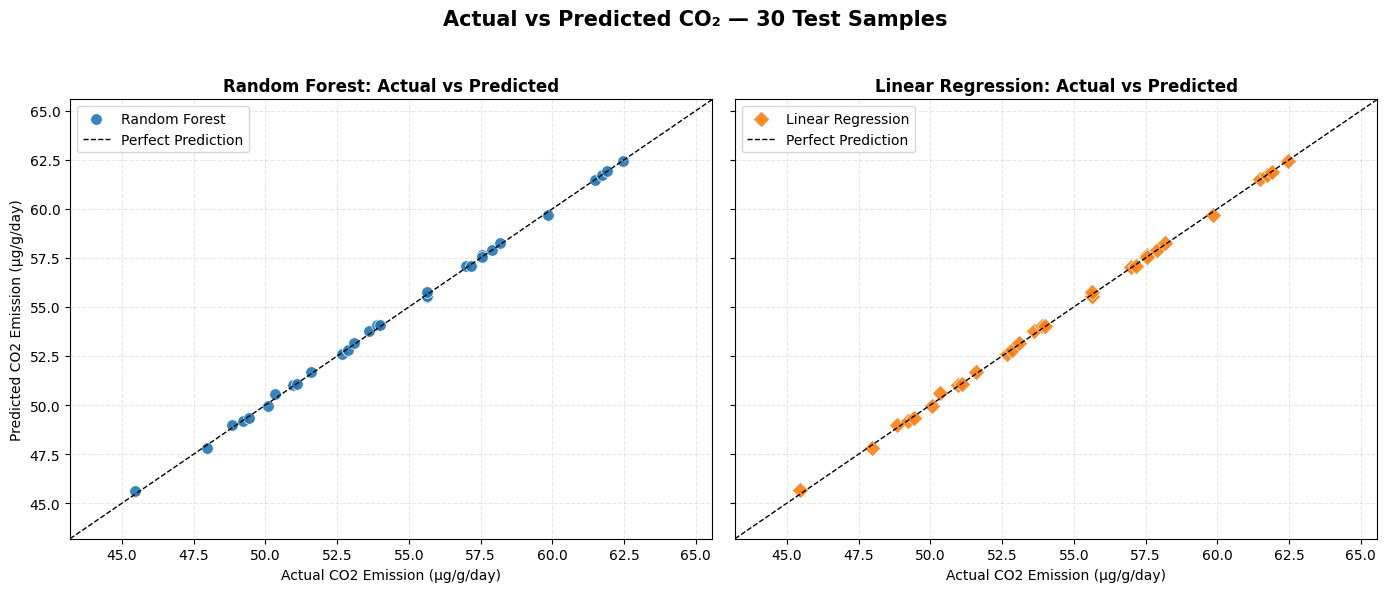

In [5]:
# ==============================
# PLOT: Actual vs Predicted (Random Forest & Linear Regression)
# ==============================
import matplotlib.pyplot as plt

# Extract trained pipelines from the loop
pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', models["Random Forest"])
])
pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', models["Linear Regression"])
])

# Predict on test set using trained pipelines
y_pred_rf = pipe_rf.predict(X_test)
y_pred_lr = pipe_lr.predict(X_test)

# Build a dataframe for plotting
df_plot = pd.DataFrame({
    'Actual': y_test.values.ravel(),
    'Pred_RF': y_pred_rf.ravel(),
    'Pred_LR': y_pred_lr.ravel()
})

# Take a subset for readability
n_points = min(30, len(df_plot))
sample_df = df_plot.sample(n=n_points, random_state=42).sort_values('Actual').reset_index(drop=True)

# Shared limits for the 45-degree line
lims = [sample_df.min().min() * 0.95, sample_df.max().max() * 1.05]

# Create side-by-side scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Random Forest
axes[0].scatter(sample_df['Actual'], sample_df['Pred_RF'],
                s=70, alpha=0.9, edgecolor='w', linewidth=0.6, color='#1f77b4', label='Random Forest')
axes[0].plot(lims, lims, 'k--', linewidth=1, label='Perfect Prediction')
axes[0].set_xlabel('Actual CO2 Emission (µg/g/day)')
axes[0].set_ylabel('Predicted CO2 Emission (µg/g/day)')
axes[0].set_title('Random Forest: Actual vs Predicted', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3, linestyle='--')
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)

# Linear Regression
axes[1].scatter(sample_df['Actual'], sample_df['Pred_LR'],
                s=70, alpha=0.9, edgecolor='w', linewidth=0.6, color='#ff7f0e', marker='D', label='Linear Regression')
axes[1].plot(lims, lims, 'k--', linewidth=1, label='Perfect Prediction')
axes[1].set_xlabel('Actual CO2 Emission (µg/g/day)')
axes[1].set_title('Linear Regression: Actual vs Predicted', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].set_xlim(lims)
axes[1].set_ylim(lims)

plt.suptitle(f'Actual vs Predicted CO₂ — {n_points} Test Samples', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()